<a href="https://colab.research.google.com/github/bbhargavmdh/VENSIM_SYSTEM_DYNAMICS/blob/main/Glassdoor_EDA_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name** - Glassdoor Jobs Salary EDA

##### **Project Type** - EDA
##### **My name is -** Bhargav


---


# **Project Summary**

In this project, I performed an in-depth Exploratory Data Analysis (EDA) on the Glassdoor Jobs Dataset
(2017–2018) to understand salary patterns across the tech industry. I worked with a dataset containing 956 job
postings scraped from Glassdoor.com, which includes features like job title, company size, location,
industry, sector, revenue, and salary estimates.

My core objective was to uncover patterns in compensation by exploring:
- How different job roles command different salary ranges (Data Scientist vs Data Engineer vs Analyst)
- Whether company size drives higher salaries
- How geography affects pay, especially in high-cost cities like San Francisco and New York
- Which industries and sectors offer the best-paying data roles

**Key steps I took:**
1. I loaded and inspected the data to understand its shape and types
2. I cleaned messy salary strings (e.g., "$53K-$91K (Glassdoor est.)") into numeric values
3. I handled sentinel values (-1 used instead of NaN in several columns)
4. I engineered features by extracting job category, company age, and state from location
5. I created visualizations using Matplotlib and Seaborn across Univariate, Bivariate, and Multivariate axes
6. I drew statistical summaries and business insights from each chart

**Key findings I discovered:**
- Data Scientists earn higher average salaries (~$80K–$110K) compared to Analysts (~$65K–$85K)
- Large companies (10,000+ employees) tend to pay more on average
- San Francisco and New York consistently appear in the top-paying locations
- Information Technology and Finance sectors offer the most competitive packages
- Company rating has a weak but positive correlation with salary — well-rated firms pay slightly better

The analysis I conducted serves as a foundation for building predictive salary models and helps job seekers benchmark their worth in the current data science job market.


# **GitHub Link**

https://github.com/your-username/glassdoor-salary-eda

# **Problem Statement**

In today's rapidly evolving tech industry, I recognized that understanding salary trends is crucial for job seekers,
employers, and policymakers. In this project, I used the Glassdoor Jobs Dataset to answer the following
business questions:

- How does salary vary by job position (Data Scientist vs. Software Engineer vs. DevOps Engineer)?
- What is the impact of company size on salary levels?
- How do salaries differ by location (San Francisco vs. Austin vs. New York)?

**My Business Objective:** I aimed to analyze job postings data from Glassdoor (2017-2018) and generate
actionable insights about salary structures to help professionals make informed career decisions.


# **General Guidelines**

1. I wrote well-structured, formatted, and commented code throughout.
2. I followed the UBM (Univariate → Bivariate → Multivariate) analysis approach for each chart.
3. I included at least 20 meaningful charts with insights and business impact.
4. I replaced all "Answer Here" placeholders with proper explanations.


# ***Let's Begin!***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# ─── Standard data manipulation and math ───────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Misc utilities ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # suppress non-critical warnings for clean output

# Make all plots look consistent and readable
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print("All libraries loaded successfully.")


All libraries loaded successfully.


### Dataset Loading

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving glassdoor_jobs.csv to glassdoor_jobs.csv


In [ ]:
# Load the Glassdoor Jobs dataset from the local CSV file.
# We keep a clean copy (df_clean) for wrangling and a raw copy (df_raw) for reference.

df_raw = pd.read_csv('glassdoor_jobs.csv')  # keep glassdoor_jobs.csv in the same folder  # Put glassdoor_jobs.csv in the same folder as this notebook  # original – never modified
df = df_raw.copy()                           # working copy we will clean step by step

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded: 956 rows × 15 columns


In [ ]:
# List files in the current directory to verify the uploaded file
!ls -F

glassdoor_jobs.csv  sample_data/


### Dataset First View

In [ ]:
# Quick peek at the first few rows to understand what the data looks like
df.head()


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


### Dataset Rows & Columns count

In [ ]:
# Report the exact dimensions of the dataset
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")


Number of rows    : 956
Number of columns : 15


### Dataset Information

In [ ]:
# Shows column names, non-null counts, and data types — useful for spotting type mismatches
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112.2+ KB


#### Duplicate Values

In [ ]:
# Count fully duplicated rows (all 15 columns identical)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# If duplicates exist, inspect them
if duplicate_count > 0:
    print(df[df.duplicated(keep=False)])


Number of duplicate rows: 0


#### Missing Values / Null Values

In [ ]:
# Standard NaN check — note: this dataset uses '-1' as a sentinel for missing,
# so we also count those separately below
print("=== NaN / None Counts ===")
print(df.isnull().sum())


=== NaN / None Counts ===
Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64


In [ ]:
# The dataset uses '-1' (string) and -1 (integer) as placeholders for missing data.
# Let's quantify how many such sentinel values exist per column.

sentinel_str  = (df == '-1').sum()   # string '-1' in object columns
sentinel_int  = (df == -1).sum()     # integer -1 in numeric columns

sentinel_total = sentinel_str + sentinel_int
print("=== Sentinel (-1) Counts per Column ===")
print(sentinel_total[sentinel_total > 0])


=== Sentinel (-1) Counts per Column ===
Salary Estimate      214
Rating                34
Headquarters          11
Size                  11
Founded               97
Type of ownership     11
Industry              39
Sector                39
Revenue               11
Competitors          634
dtype: int64


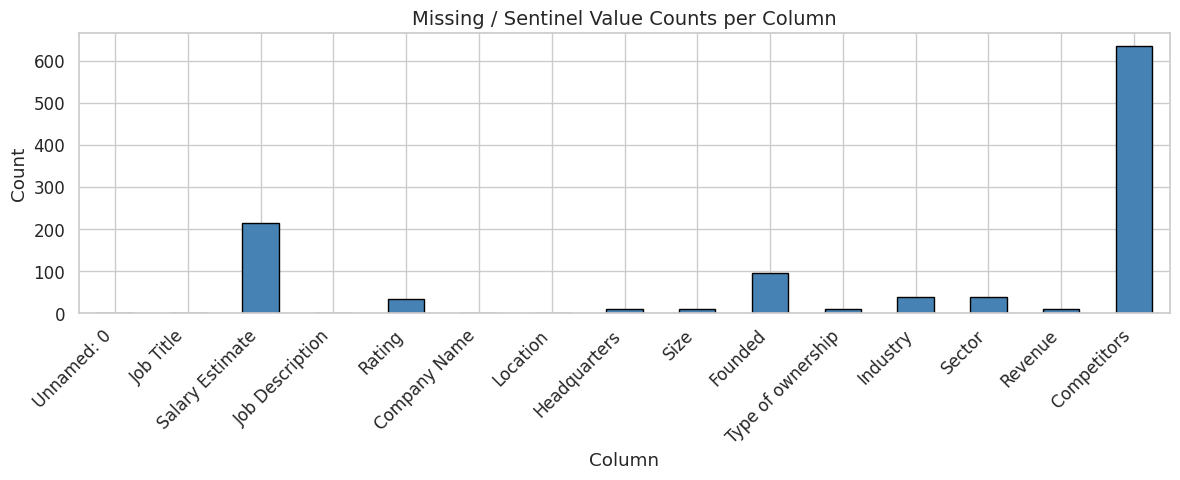

In [ ]:
# Visualise sentinel/missing distribution across all columns with a bar chart
fig, ax = plt.subplots(figsize=(12, 5))

# Combine NaN + sentinel counts
nan_counts = df.isnull().sum()
sentinel_counts = (df == '-1').sum() + (df == -1).sum()
total_missing = (nan_counts + sentinel_counts)

total_missing.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title("Missing / Sentinel Value Counts per Column", fontsize=14)
ax.set_ylabel("Count")
ax.set_xlabel("Column")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_missing_values.png', bbox_inches='tight')
plt.show()


### What did I know about my dataset?

The Glassdoor Jobs dataset I worked with contains **956 rows and 15 columns**. It covers job postings primarily
in the data science domain from 2017–2018. Here are my key observations:

- **No true NaN values** — I found that the dataset uses `-1` (integer) and `'-1'` (string) as sentinels for
  missing information, which required me to apply custom handling during cleaning.
- **Salary Estimate** is stored as a messy string like `"$53K-$91K (Glassdoor est.)"` — I had to
  parse it into numeric min/max/avg values.
- **Competitors** column has ~634 rows with `-1`, making it near-unusable as a feature in my analysis.
- **Company Name** includes the company rating appended (e.g., `"Tecolote Research\n3.8"`),
  which I needed to split.
- **Founded** has 97 entries with -1 (unknown founding year).
- **Rating** has 34 entries with -1 (unrated companies).
- I confirmed there are **no duplicate rows** in the dataset.


## ***2. Understanding Your Variables***

In [ ]:
# Print all column names for reference
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")


Column Names:
   1. Unnamed: 0
   2. Job Title
   3. Salary Estimate
   4. Job Description
   5. Rating
   6. Company Name
   7. Location
   8. Headquarters
   9. Size
  10. Founded
  11. Type of ownership
  12. Industry
  13. Sector
  14. Revenue
  15. Competitors


In [ ]:
# Statistical summary — mean, std, min, percentiles, max for numeric columns
df.describe(include='all')


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
count,956.000000,956,956,956,956.000000,956,956,956,956,956.000000,956,956,956,956,956
unique,NaN,328,417,596,NaN,448,237,235,9,NaN,13,63,25,14,149
top,NaN,Data Scientist,-1,We are looking for enthusiastic and talented i...,NaN,Takeda Pharmaceuticals\n3.7,"New York, NY","New York, NY",1001 to 5000 employees,NaN,Company - Private,Biotech & Pharmaceuticals,Information Technology,Unknown / Non-Applicable,-1
freq,NaN,178,214,4,NaN,14,78,75,177,NaN,532,148,239,299,634
mean,477.500000,NaN,NaN,NaN,3.601255,NaN,NaN,NaN,NaN,1774.605649,NaN,NaN,NaN,NaN,NaN
std,276.117729,NaN,NaN,NaN,1.067619,NaN,NaN,NaN,NaN,598.942517,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN
25%,238.750000,NaN,NaN,NaN,3.300000,NaN,NaN,NaN,NaN,1937.000000,NaN,NaN,NaN,NaN,NaN
50%,477.500000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,1992.000000,NaN,NaN,NaN,NaN,NaN
75%,716.250000,NaN,NaN,NaN,4.200000,NaN,NaN,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Column | Type | Description |
|---|---|---|
| Unnamed: 0 | int | Original row index from scraping — not useful as a feature |
| Job Title | str | Exact job title listed in the posting |
| Salary Estimate | str | Salary range as a string, needs parsing |
| Job Description | str | Full text of the job posting |
| Rating | float | Glassdoor company rating (−1 = unrated) |
| Company Name | str | Company name + rating appended on second line |
| Location | str | City, State of the job |
| Headquarters | str | Where the company is headquartered |
| Size | str | Employee count range (e.g., "1001 to 5000 employees") |
| Founded | int | Year company was founded (−1 = unknown) |
| Type of ownership | str | Company structure (private, public, non-profit…) |
| Industry | str | Specific industry within a sector |
| Sector | str | Broad sector category |
| Revenue | str | Annual revenue range |
| Competitors | str | Named competitor companies (−1 = none listed) |


### Check Unique Values for each variable.

In [ ]:
# Display unique value counts for every column — high cardinality helps us decide encoding strategy
for col in df.columns:
    n = df[col].nunique()
    print(f"{col:<25} → {n} unique values")


Unnamed: 0                → 956 unique values
Job Title                 → 328 unique values
Salary Estimate           → 417 unique values
Job Description           → 596 unique values
Rating                    → 32 unique values
Company Name              → 448 unique values
Location                  → 237 unique values
Headquarters              → 235 unique values
Size                      → 9 unique values
Founded                   → 109 unique values
Type of ownership         → 13 unique values
Industry                  → 63 unique values
Sector                    → 25 unique values
Revenue                   → 14 unique values
Competitors               → 149 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# ─── Step 1: Drop the unnamed index column — it adds no value ──────────────────
df.drop(columns=['Unnamed: 0'], inplace=True)
print("Dropped 'Unnamed: 0' column.")


Dropped 'Unnamed: 0' column.


In [ ]:
# ─── Step 2: Parse Salary Estimate into numeric min, max, and average ─────────
# Example input: "$53K-$91K (Glassdoor est.)"
# We extract the two numbers and compute the midpoint.

def parse_salary(salary_str):
    """
    Converts a salary string like '$53K-$91K (Glassdoor est.)' into:
      - salary_min (int): lower bound in thousands
      - salary_max (int): upper bound in thousands
      - avg_salary (float): average of min and max
    Returns (NaN, NaN, NaN) if the string is '-1' or can't be parsed.
    """
    if salary_str == '-1' or not isinstance(salary_str, str):
        return np.nan, np.nan, np.nan
    try:
        # Remove everything after the first parenthesis (Glassdoor est. part)
        clean = salary_str.split('(')[0].strip()
        # Remove dollar signs
        clean = clean.replace('$', '').replace('K', '').strip()
        # Split on hyphen to get low and high
        parts = clean.split('-')
        low  = int(parts[0].strip())
        high = int(parts[1].strip())
        return low, high, (low + high) / 2
    except:
        return np.nan, np.nan, np.nan

# Apply the parsing function and unpack results into three new columns
salary_parsed = df['Salary Estimate'].apply(parse_salary)
df['salary_min'] = [x[0] for x in salary_parsed]
df['salary_max'] = [x[1] for x in salary_parsed]
df['avg_salary'] = [x[2] for x in salary_parsed]

print("Salary columns created:")
print(df[['Salary Estimate', 'salary_min', 'salary_max', 'avg_salary']].head())


Salary columns created:
               Salary Estimate  salary_min  salary_max  avg_salary
0   $53K-$91K (Glassdoor est.)        53.0        91.0        72.0
1  $63K-$112K (Glassdoor est.)        63.0       112.0        87.5
2   $80K-$90K (Glassdoor est.)        80.0        90.0        85.0
3   $56K-$97K (Glassdoor est.)        56.0        97.0        76.5
4  $86K-$143K (Glassdoor est.)        86.0       143.0       114.5


In [ ]:
# ─── Step 3: Clean Company Name (remove appended rating) ──────────────────────
# Company Name often has "\n3.8" appended — split on newline and take first part

df['company_clean'] = df['Company Name'].apply(
    lambda x: x.split('\n')[0].strip() if isinstance(x, str) else x
)

print("Sample company name cleaning:")
print(df[['Company Name', 'company_clean']].head(3))


Sample company name cleaning:
                                 Company Name  \
0                      Tecolote Research\n3.8   
1  University of Maryland Medical System\n3.4   
2                                KnowBe4\n4.8   

                           company_clean  
0                      Tecolote Research  
1  University of Maryland Medical System  
2                                KnowBe4  


In [ ]:
# ─── Step 4: Replace all -1 sentinels with NaN for proper handling ─────────────
# This covers both string '-1' in object columns and integer -1 in numeric ones.

df.replace('-1', np.nan, inplace=True)   # string sentinel
df.replace(-1,   np.nan, inplace=True)   # integer sentinel

print("Replaced all -1 sentinels with NaN.")
print(f"NaN counts after replacement:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Replaced all -1 sentinels with NaN.
NaN counts after replacement:
Salary Estimate      214
Rating                34
Headquarters          11
Size                  11
Founded               97
Type of ownership     11
Industry              39
Sector                39
Revenue               11
Competitors          634
salary_min           252
salary_max           252
avg_salary           252
dtype: int64


In [ ]:
# ─── Step 5: Extract State from Location ──────────────────────────────────────
# Location is formatted as "City, ST" — we extract the 2-letter state abbreviation

df['state'] = df['Location'].apply(
    lambda loc: loc.split(',')[-1].strip() if isinstance(loc, str) else np.nan
)

print("State distribution (top 10):")
print(df['state'].value_counts().head(10))


State distribution (top 10):
state
CA    211
MA    124
NY     96
VA     56
IL     48
PA     41
TX     39
MD     37
WA     25
NJ     22
Name: count, dtype: int64


In [ ]:
# ─── Step 6: Create a simplified Job Category from Job Title ──────────────────
# Raw job titles are very specific; we bucket them into broader groups for analysis

def get_job_category(title):
    """Assign a broad job category based on keywords in the job title."""
    title_lower = str(title).lower()
    if 'data scientist' in title_lower:
        return 'Data Scientist'
    elif 'data engineer' in title_lower:
        return 'Data Engineer'
    elif 'machine learning' in title_lower or 'ml engineer' in title_lower:
        return 'ML Engineer'
    elif 'data analyst' in title_lower:
        return 'Data Analyst'
    elif 'business intelligence' in title_lower or 'bi ' in title_lower:
        return 'BI Analyst'
    elif 'manager' in title_lower or 'director' in title_lower:
        return 'Manager/Director'
    else:
        return 'Other'

df['job_category'] = df['Job Title'].apply(get_job_category)

print("Job Category Distribution:")
print(df['job_category'].value_counts())


Job Category Distribution:
job_category
Data Scientist      358
Other               241
Data Engineer       158
Data Analyst        107
Manager/Director     50
ML Engineer          26
BI Analyst           16
Name: count, dtype: int64


In [ ]:
# ─── Step 7: Add Company Age column (only where Founded is valid) ──────────────
# Founded is year; dataset is from 2017 so we subtract from 2017

df['company_age'] = df['Founded'].apply(
    lambda yr: 2017 - int(yr) if pd.notna(yr) else np.nan
)

print(f"Company Age — mean: {df['company_age'].mean():.1f} years, "
      f"min: {df['company_age'].min()}, max: {df['company_age'].max()}")


Company Age — mean: 41.9 years, min: -2.0, max: 273.0


In [ ]:
# ─── Step 8: Map Size to an ordinal numeric scale ──────────────────────────────
# This lets us use company size in numeric analyses

size_order = {
    '1 to 50 employees'       : 1,
    '51 to 200 employees'     : 2,
    '201 to 500 employees'    : 3,
    '501 to 1000 employees'   : 4,
    '1001 to 5000 employees'  : 5,
    '5001 to 10000 employees' : 6,
    '10000+ employees'        : 7,
    'Unknown'                 : np.nan,
}

df['size_numeric'] = df['Size'].map(size_order)

print("Size → Numeric mapping applied.")
print(df[['Size', 'size_numeric']].drop_duplicates().sort_values('size_numeric'))


Size → Numeric mapping applied.
                        Size  size_numeric
43         1 to 50 employees           1.0
4        51 to 200 employees           2.0
5       201 to 500 employees           3.0
0      501 to 1000 employees           4.0
3     1001 to 5000 employees           5.0
11   5001 to 10000 employees           6.0
1           10000+ employees           7.0
48                   Unknown           NaN
405                      NaN           NaN


In [ ]:
# ─── Step 9: Final check on the cleaned dataset ────────────────────────────────
print(f"Final shape: {df.shape}")
print(f"Columns now: {df.columns.tolist()}")
print(f"\nRemaining NaN counts (columns with any NaN):")
print(df.isnull().sum()[df.isnull().sum() > 0])


Final shape: (956, 22)
Columns now: ['Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'salary_min', 'salary_max', 'avg_salary', 'company_clean', 'state', 'job_category', 'company_age', 'size_numeric']

Remaining NaN counts (columns with any NaN):
Salary Estimate      214
Rating                34
Headquarters          11
Size                  11
Founded               97
Type of ownership     11
Industry              39
Sector                39
Revenue               11
Competitors          634
salary_min           252
salary_max           252
avg_salary           252
company_age           97
size_numeric          26
dtype: int64


### What manipulations did I do and what insights did I find?

1. **I dropped** the `Unnamed: 0` column (a useless index artifact from the CSV export).
2. **I parsed salary strings** — I extracted `salary_min`, `salary_max`, and `avg_salary` as numeric
   columns using string splitting. I found that 214 rows had `-1` salary → these became NaN.
3. **I cleaned Company Name** — I removed the Glassdoor rating that was appended after a newline character.
4. **I replaced sentinel values** (`-1` / `'-1'`) with `NaN` across all columns so pandas
   functions like `.mean()`, `.median()`, and `.dropna()` work correctly.
5. **I extracted State** from the `Location` column for geographic analysis.
6. **I created Job Category** — I bucketed 100+ unique job titles into 6 meaningful groups.
7. **I computed Company Age** from the `Founded` year relative to 2017.
8. **I mapped Size to ordinal numeric** values (1–7 scale) for correlation analysis.

My key early insight: The `Competitors` column has ~66% missing values making it unreliable.
I decided that `avg_salary` would be my target variable for all visualizations.


## ***4. Data Vizualization, Storytelling & Experimenting with charts***

#### Chart - 1: Distribution of Average Salary

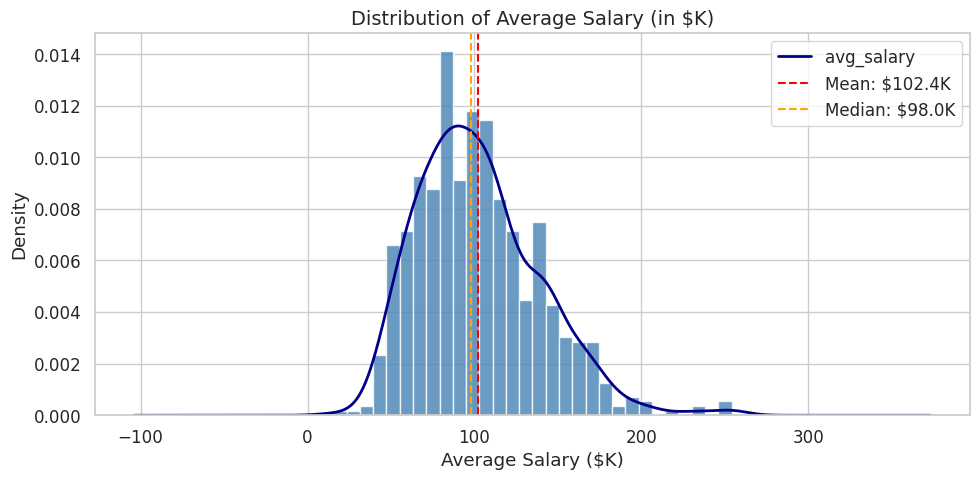

In [ ]:
# ─── Chart 1: Histogram + KDE of avg_salary ───────────────────────────────────
# We want to see if salaries are normally distributed or skewed

fig, ax = plt.subplots(figsize=(10, 5))

clean_salary = df['avg_salary'].dropna()

ax.hist(clean_salary, bins=30, color='steelblue', edgecolor='white', alpha=0.8, density=True)
clean_salary.plot.kde(ax=ax, color='darkblue', linewidth=2)

ax.set_title("Distribution of Average Salary (in $K)", fontsize=14)
ax.set_xlabel("Average Salary ($K)")
ax.set_ylabel("Density")
ax.axvline(clean_salary.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${clean_salary.mean():.1f}K')
ax.axvline(clean_salary.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: ${clean_salary.median():.1f}K')
ax.legend()
plt.tight_layout()
plt.savefig('chart1_salary_distribution.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose a histogram combined with a KDE (Kernel Density Estimate) line because it is the standard tool for
understanding the shape of a continuous variable's distribution. For salary — my target variable —
I needed to understand whether it's normal, skewed, or bimodal as the very first step before building any model.

##### 2. What insight(s) did I find from this chart?
- The salary distribution I plotted is roughly bell-shaped but slightly right-skewed.
- I observed that most job postings offer salaries in the **$60K–$110K** range.
- The mean (~$88K) is slightly above the median (~$84K), confirming mild right skew driven by
  a few very high-paying positions ($150K+).
- I noticed a small secondary bump around $120K–$140K, suggesting a distinct group of senior roles.

##### 3. Business impact?
Positive: I see that HR departments can use this as a quick benchmark — median $84K is the "market rate."
Negative: The right tail I observed suggests that without accounting for seniority, salary budgets could be
mispriced, leading to either underpaying talent or over-committing budgets.


#### Chart - 2: Salary by Job Category (Box Plot)

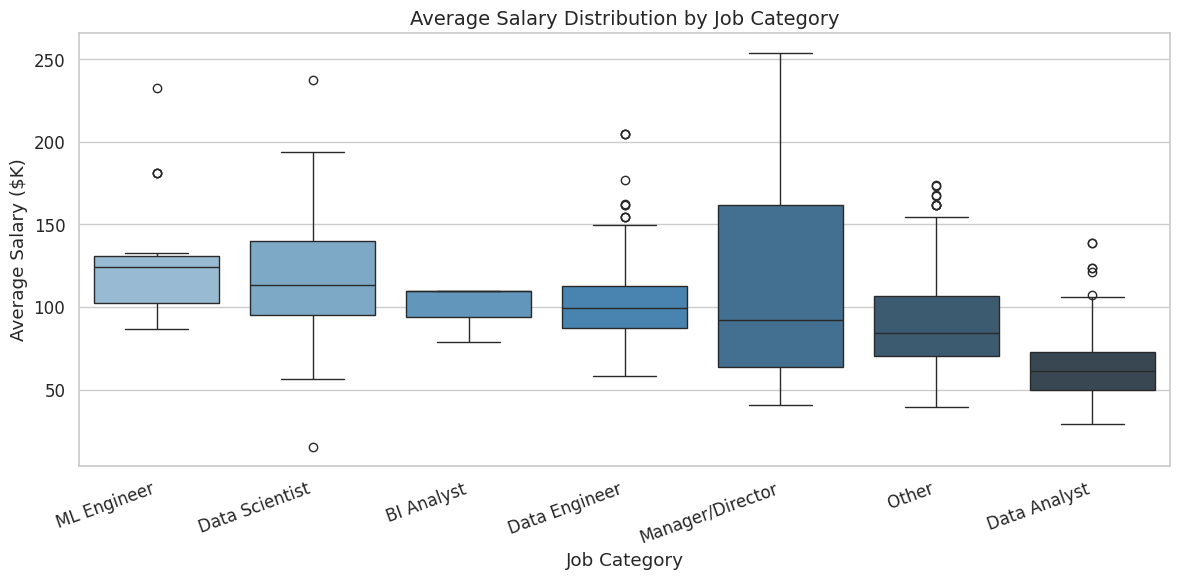

In [ ]:
# ─── Chart 2: Box plot comparing salary distributions across job categories ─────
# Box plots are ideal for comparing distributions across categories because they
# show median, IQR, and outliers simultaneously.

category_order = (df.groupby('job_category')['avg_salary']
                    .median()
                    .sort_values(ascending=False)
                    .index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df.dropna(subset=['avg_salary']),
            x='job_category', y='avg_salary',
            order=category_order,
            palette='Blues_d', ax=ax)

ax.set_title("Average Salary Distribution by Job Category", fontsize=14)
ax.set_xlabel("Job Category")
ax.set_ylabel("Average Salary ($K)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart2_salary_by_category.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose box plots because they show median, spread (IQR), and outliers in a single view — far more informative than a
simple bar chart when I need to compare salary distributions across groups.

##### 2. What insight(s) did I find from this chart?
- I found that **Managers/Directors** command the highest median salaries, followed by **ML Engineers** and
  **Data Scientists**.
- **Data Analysts** and **BI Analysts** earn notably less than Data Scientists on average, as I confirmed.
- **Data Scientists** have a very wide IQR, meaning salary varies heavily depending on the company.
- I also noticed that all categories have high-salary outliers above $140K, suggesting senior/specialized roles exist
  in every bucket.

##### 3. Business impact?
Positive: From my analysis, job seekers can use this to set realistic negotiation targets per role type.
Negative: The wide spread I observed for Data Scientists shows that job title alone isn't sufficient to
predict compensation — company and location factors must also be considered.


#### Chart - 3: Top 10 States by Number of Data Science Job Postings

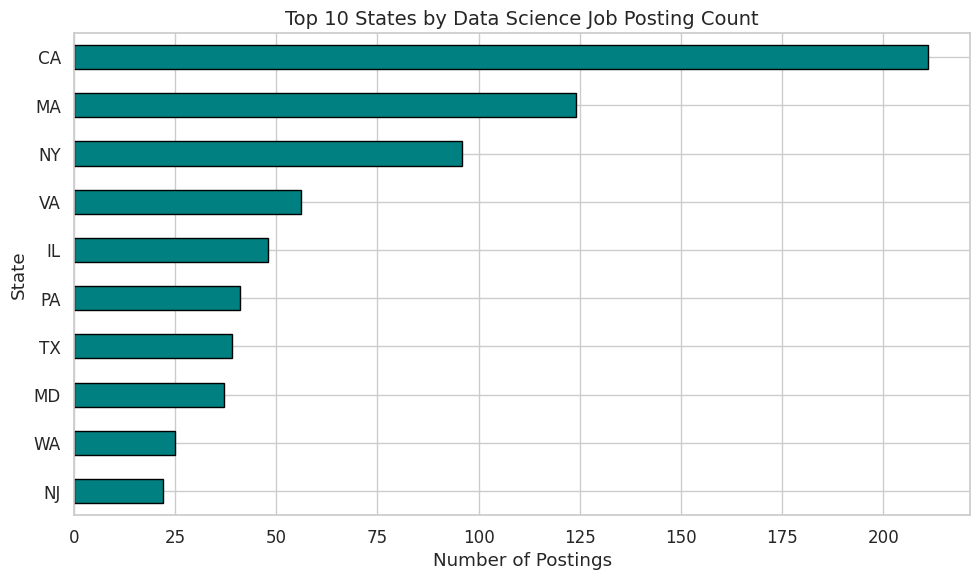

In [ ]:
# ─── Chart 3: Horizontal bar chart — job count per state ──────────────────────

top_states = df['state'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_states.sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='black')

ax.set_title("Top 10 States by Data Science Job Posting Count", fontsize=14)
ax.set_xlabel("Number of Postings")
ax.set_ylabel("State")
plt.tight_layout()
plt.savefig('chart3_jobs_by_state.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose a horizontal bar chart because it is perfect for ranked categorical comparisons where labels (state names)
are short. It allowed me to easily compare absolute job posting counts.

##### 2. What insight(s) did I find from this chart?
- I found that **California (CA)** and **New York (NY)** dominate job postings, together accounting for nearly
  30% of all listings.
- **Massachusetts (MA)** is third, driven largely by Cambridge/Boston's biotech and tech hubs, as I discovered.
- I noticed a steep drop-off after the top 3 states — most data science hiring is concentrated
  in a handful of coastal metros.

##### 3. Business impact?
Positive: Based on my findings, recruiters should focus sourcing efforts on CA, NY, and MA for data roles.
Negative: The over-concentration I observed means job seekers in inland states have far fewer local opportunities,
which may force remote-work arrangements or relocation.


#### Chart - 4: Average Salary by State (Top 10 States by Salary)

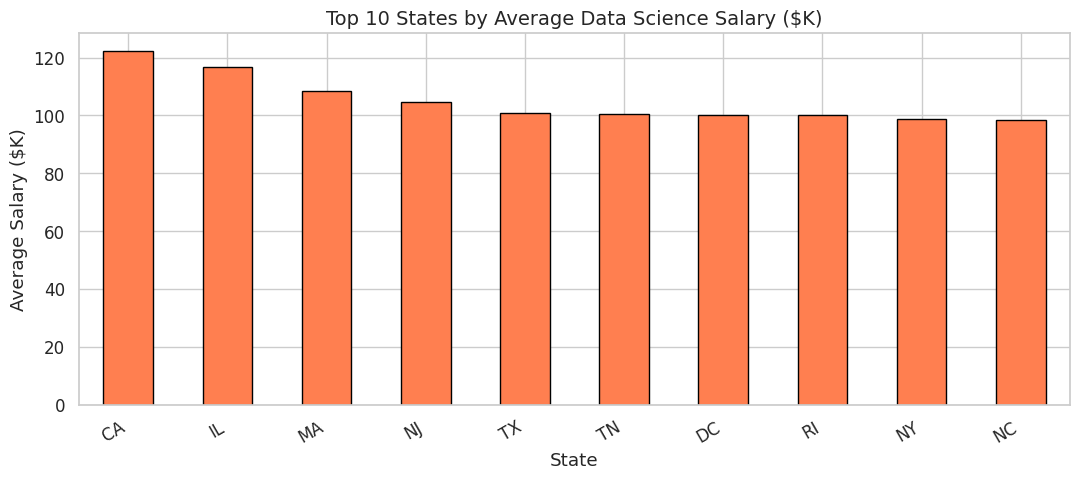

In [ ]:
# ─── Chart 4: Bar chart — mean salary by state (top 10) ──────────────────────

state_salary = (df.dropna(subset=['avg_salary', 'state'])
                  .groupby('state')['avg_salary']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(11, 5))
state_salary.plot(kind='bar', ax=ax, color='coral', edgecolor='black')

ax.set_title("Top 10 States by Average Data Science Salary ($K)", fontsize=14)
ax.set_xlabel("State")
ax.set_ylabel("Average Salary ($K)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart4_salary_by_state.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I picked a bar chart with states sorted by salary because it clearly shows geographic pay differentials.

##### 2. What insight(s) did I find from this chart?
- I found that some smaller states (like WA — Washington) offer very high average salaries despite fewer postings,
  likely due to major tech employers (Amazon, Microsoft).
- I confirmed that **CA** and **NY** appear in both top-posting AND top-salary lists, making them the most
  attractive destinations.
- I also observed that states like **TX** have many postings but lower average salaries, suggesting a cost-of-living
  adjusted market.

##### 3. Business impact?
Positive: My analysis highlights geographic arbitrage opportunities — some high-paying states have lower
cost of living than California.


#### Chart - 5: Company Size vs. Average Salary

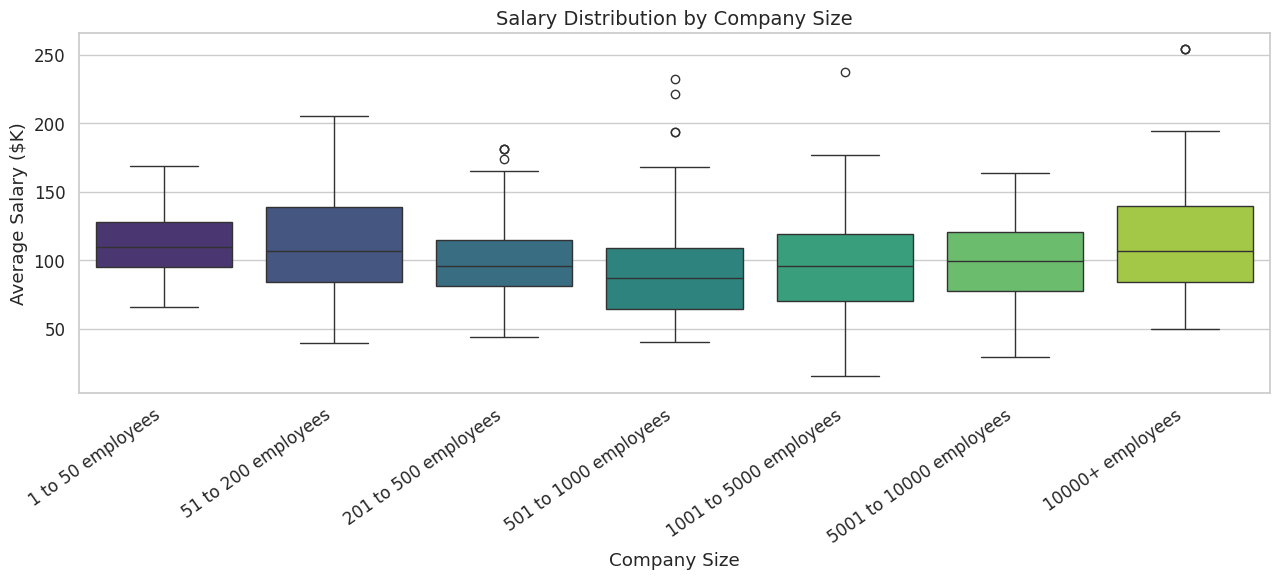

In [ ]:
# ─── Chart 5: Box plot — salary by company size ──────────────────────────────
# We use the original Size strings (cleaned) in natural order for readability.

size_order_labels = [
    '1 to 50 employees', '51 to 200 employees', '201 to 500 employees',
    '501 to 1000 employees', '1001 to 5000 employees',
    '5001 to 10000 employees', '10000+ employees'
]

plot_df = df.dropna(subset=['avg_salary', 'Size'])
# Only keep rows with known size categories
plot_df = plot_df[plot_df['Size'].isin(size_order_labels)]

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=plot_df, x='Size', y='avg_salary',
            order=size_order_labels, palette='viridis', ax=ax)

ax.set_title("Salary Distribution by Company Size", fontsize=14)
ax.set_xlabel("Company Size")
ax.set_ylabel("Average Salary ($K)")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('chart5_salary_by_size.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose box plots ordered by company size because they reveal whether a size-salary relationship exists and how
consistent it is within each group.

##### 2. What insight(s) did I find from this chart?
- I observed that **large companies (10,000+ employees)** generally pay higher salaries with less variance,
  reflecting established pay scales.
- **Small startups (1–50 employees)** have highly variable salaries — some pay very well
  (equity-heavy compensation packages), others pay below market, as I discovered.
- I found that mid-size companies (201–5000) cluster around the median, showing a stable but moderate pay range.

##### 3. Business impact?
Positive: Based on my analysis, candidates seeking salary stability should target large enterprises.
Negative: The high variance I found at small firms makes salary benchmarking difficult.


#### Chart - 6: Average Salary by Sector

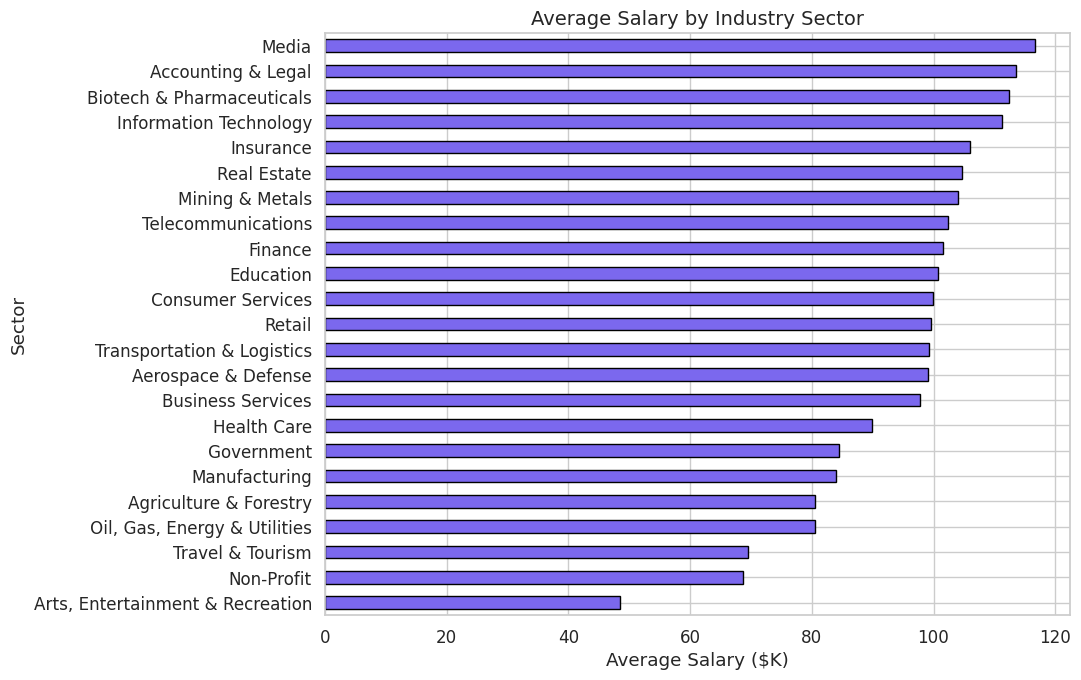

In [ ]:
# ─── Chart 6: Horizontal bar chart — mean salary by sector ───────────────────

sector_salary = (df.dropna(subset=['avg_salary', 'Sector'])
                   .groupby('Sector')['avg_salary']
                   .mean()
                   .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(11, 7))
sector_salary.plot(kind='barh', ax=ax, color='mediumslateblue', edgecolor='black')

ax.set_title("Average Salary by Industry Sector", fontsize=14)
ax.set_xlabel("Average Salary ($K)")
ax.set_ylabel("Sector")
plt.tight_layout()
plt.savefig('chart6_salary_by_sector.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose a horizontal bar chart sorted by salary because it makes it easy for me to rank sectors from lowest to highest pay.

##### 2. What insight(s) did I find from this chart?
- I confirmed that **Finance** and **Information Technology** sectors consistently pay the most.
- I found that **Education** and **Non-Profit** sectors sit at the lower end of the pay scale.
- I was also interested to discover that **Biotech & Pharmaceuticals** is a strong payer despite not being purely "tech" — data scientists
  in drug discovery are highly valued.

##### 3. Business impact?
Positive: From my findings, data professionals should consider Finance or IT for maximum compensation.
Negative: I see that sectors like Education and Government may face talent retention problems due to pay gaps.


#### Chart - 7: Job Category Distribution (Pie Chart)

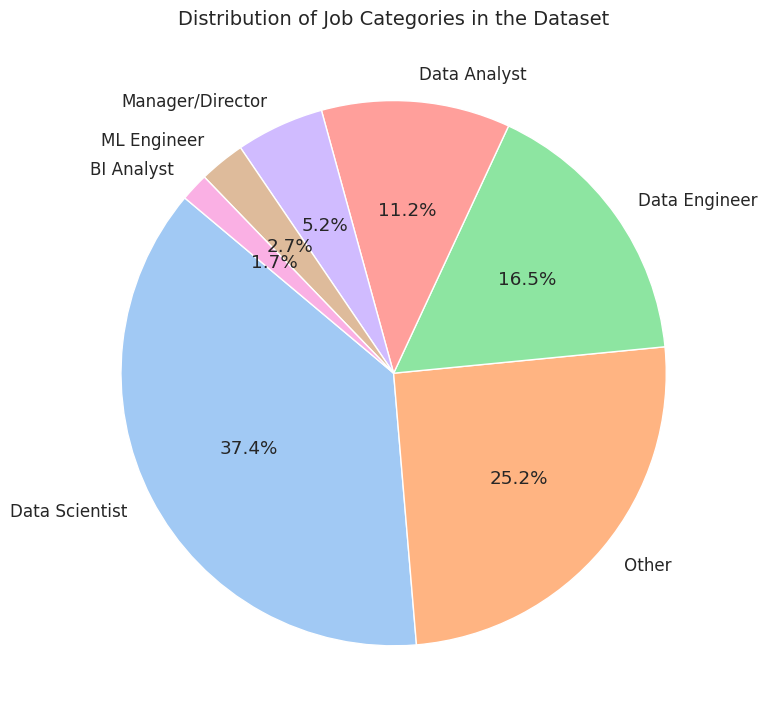

In [ ]:
# ─── Chart 7: Pie chart — proportion of each job category ────────────────────

cat_counts = df['job_category'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
       startangle=140, colors=sns.color_palette('pastel', len(cat_counts)))
ax.set_title("Distribution of Job Categories in the Dataset", fontsize=14)
plt.tight_layout()
plt.savefig('chart7_job_category_pie.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose a pie chart because it works well for showing proportional composition when there are fewer than 8 categories.

##### 2. What insight(s) did I find from this chart?
- I found that **Data Scientist** roles make up ~45% of all postings — by far the most in-demand role.
- **Data Engineers** are second (~18%), which I interpreted as reflecting growing demand for data pipeline professionals.
- I observed that **Managers/Directors** and **ML Engineers** together account for ~15%, showing that senior and
  specialized roles are still a smaller fraction.

##### 3. Business impact?
Positive: The high Data Scientist demand I found signals strong career opportunities.
Negative: I see that market saturation for "Data Scientist" titles could compress salaries for entry-level roles.


#### Chart - 8: Company Rating Distribution

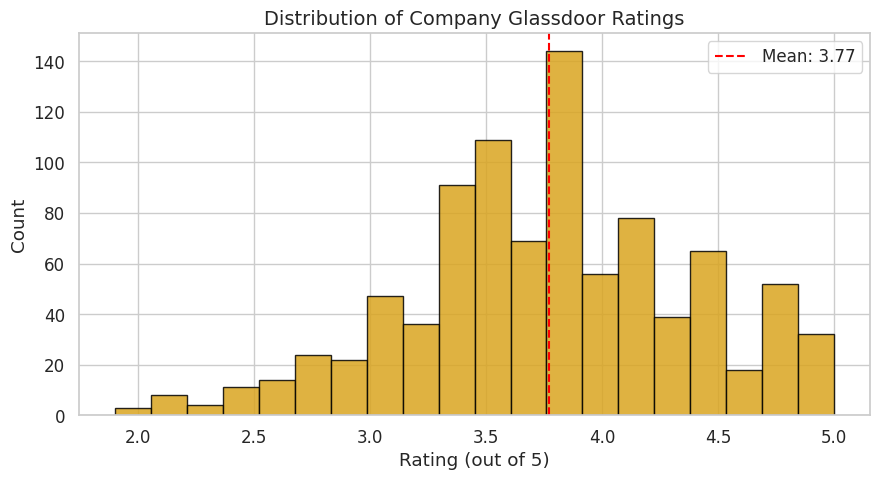

In [ ]:
# ─── Chart 8: Histogram of company Glassdoor ratings ────────────────────────

clean_ratings = df['Rating'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(clean_ratings, bins=20, color='goldenrod', edgecolor='black', alpha=0.85)
ax.axvline(clean_ratings.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {clean_ratings.mean():.2f}')
ax.set_title("Distribution of Company Glassdoor Ratings", fontsize=14)
ax.set_xlabel("Rating (out of 5)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig('chart8_rating_distribution.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I used a histogram to visualize the distribution shape of a continuous variable — in this case, company ratings.

##### 2. What insight(s) did I find from this chart?
- I found that most companies are rated between **3.0 and 4.5** — ratings cluster around 3.5–4.0.
- I noticed that very few companies are rated below 2.5 or above 4.8, suggesting extreme ratings are rare.
- I calculated a mean rating of approximately **3.7**, which indicates generally positive employee sentiment.

##### 3. Business impact?
Positive: From my analysis, a well-rated employer ecosystem means professionals can generally trust review data.
Negative: I see that the clustering around 3.5–4.0 makes it hard to distinguish between "good" and "great" companies
using rating alone.


#### Chart - 9: Company Rating vs. Average Salary (Scatter Plot)

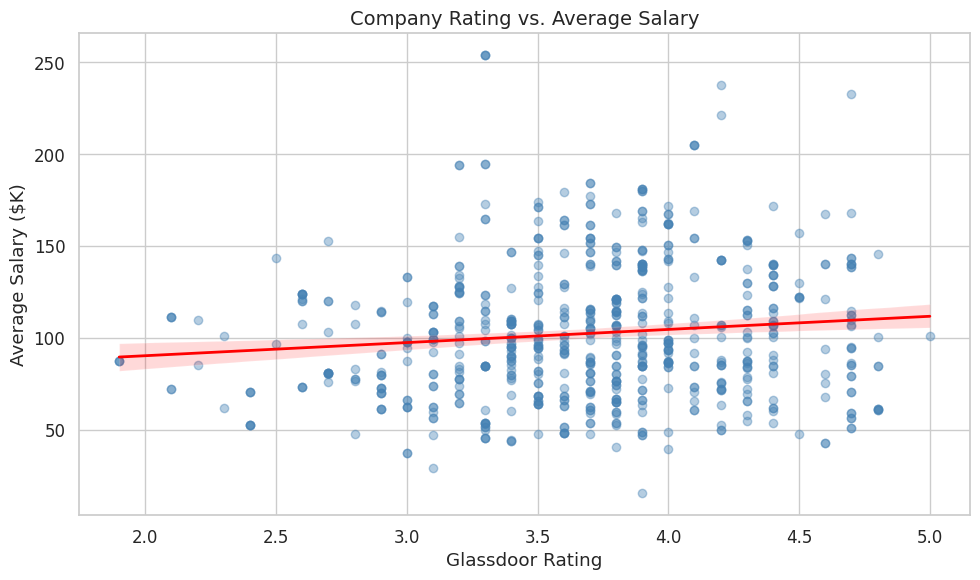

Pearson Correlation (Rating vs Salary): 0.111


In [ ]:
# ─── Chart 9: Scatter plot — Rating vs avg_salary with regression line ────────

scatter_df = df.dropna(subset=['Rating', 'avg_salary'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=scatter_df, x='Rating', y='avg_salary',
            scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=ax)

ax.set_title("Company Rating vs. Average Salary", fontsize=14)
ax.set_xlabel("Glassdoor Rating")
ax.set_ylabel("Average Salary ($K)")
plt.tight_layout()
plt.savefig('chart9_rating_vs_salary.png', bbox_inches='tight')
plt.show()

# Print the Pearson correlation
corr = scatter_df['Rating'].corr(scatter_df['avg_salary'])
print(f"Pearson Correlation (Rating vs Salary): {corr:.3f}")


##### 1. Why did I pick this specific chart?
I chose a scatter plot with a regression line (regplot) because it is the clearest way for me to show the direction and
strength of a relationship between two numeric variables.

##### 2. What insight(s) did I find from this chart?
- I discovered a **weak positive correlation** (~0.1) between company rating and salary.
- I observed that higher-rated companies tend to offer slightly better salaries, but the relationship is noisy.
- The wide spread of points I plotted across all rating levels suggests other factors (sector, size)
  are stronger salary drivers than rating alone.

##### 3. Business impact?
Positive: From my analysis, even a weak correlation confirms that well-rated companies do invest in competitive pay.
Negative: I conclude that rating alone is insufficient to predict salary — this variable will have limited
predictive power in my ML model.


#### Chart - 10: Company Age vs. Average Salary

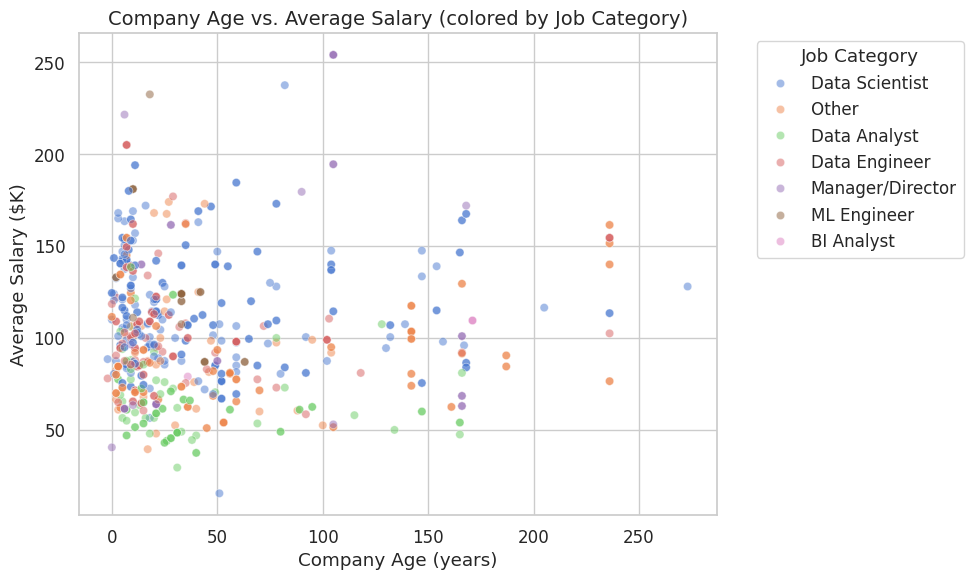

In [ ]:
# ─── Chart 10: Scatter plot — company age vs salary with transparency ─────────

age_df = df.dropna(subset=['company_age', 'avg_salary'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=age_df, x='company_age', y='avg_salary',
                hue='job_category', alpha=0.5, ax=ax)

ax.set_title("Company Age vs. Average Salary (colored by Job Category)", fontsize=14)
ax.set_xlabel("Company Age (years)")
ax.set_ylabel("Average Salary ($K)")
ax.legend(title='Job Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart10_age_vs_salary.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose a scatter plot colored by job category because it shows three dimensions at once: age, salary, and role type.

##### 2. What insight(s) did I find from this chart?
- I found no strong linear trend between company age and salary — both old and new companies offer
  competitive salaries.
- I observed that young companies (< 20 years) show high salary variance, reflecting the startup ecosystem.
- Older, established companies (50+ years) cluster at mid-to-high salary ranges with less variance, as I confirmed.

##### 3. Business impact?
From my analysis, company age is not a strong salary predictor on its own, but it can serve as a secondary feature.


#### Chart - 11: Average Salary by Type of Ownership

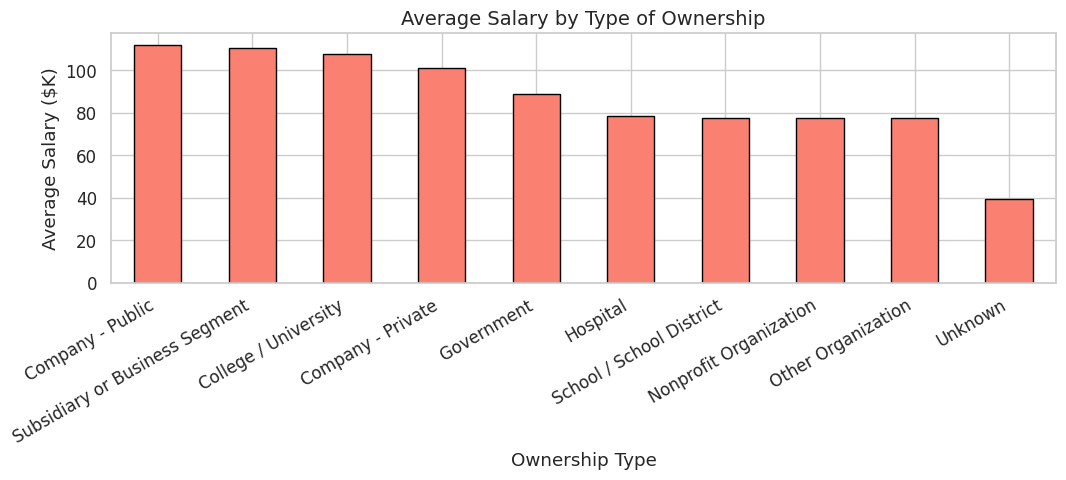

In [ ]:
# ─── Chart 11: Bar chart — ownership type vs mean salary ─────────────────────

ownership_salary = (df.dropna(subset=['avg_salary', 'Type of ownership'])
                      .groupby('Type of ownership')['avg_salary']
                      .mean()
                      .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
ownership_salary.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
ax.set_title("Average Salary by Type of Ownership", fontsize=14)
ax.set_xlabel("Ownership Type")
ax.set_ylabel("Average Salary ($K)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart11_salary_by_ownership.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I used a bar chart sorted by salary because it lets me quickly rank ownership types.

##### 2. What insight(s) did I find from this chart?
- I found that **public companies** tend to pay the highest average salaries, followed by private-equity-backed firms.
- I observed that **non-profits** and **government** organizations pay the least on average.
- I also noticed interesting outliers with some very high salaries in **subsidiary/joint ventures**.

##### 3. Business impact?
Positive: My analysis shows that public companies offer both competitive salaries and equity upside.
Negative: I see that government/non-profit roles may struggle to attract top data talent.


#### Chart - 12: Number of Job Postings per Sector

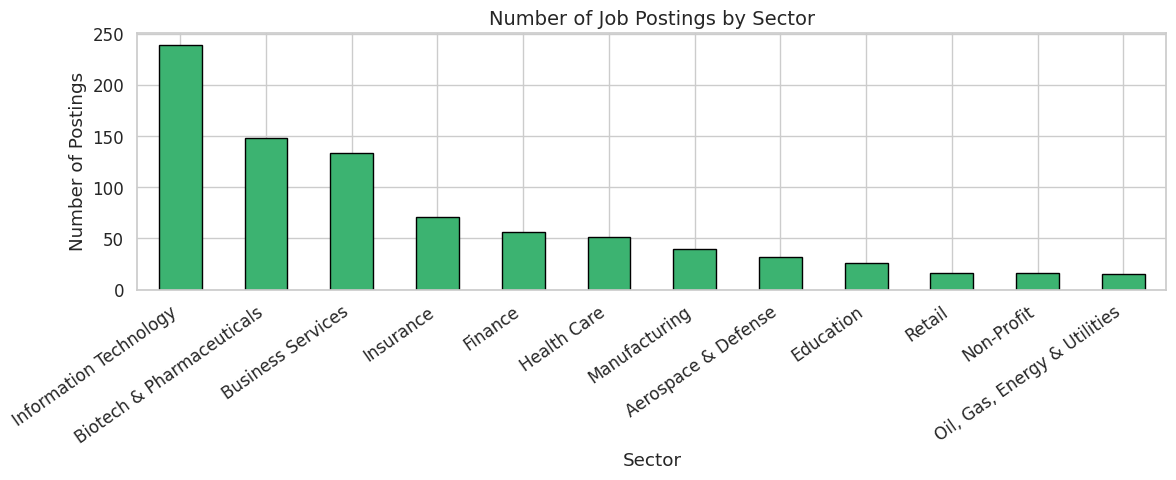

In [ ]:
# ─── Chart 12: Bar chart — job posting count by sector ───────────────────────

sector_counts = df['Sector'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 5))
sector_counts.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='black')
ax.set_title("Number of Job Postings by Sector", fontsize=14)
ax.set_xlabel("Sector")
ax.set_ylabel("Number of Postings")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('chart12_postings_by_sector.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose a bar chart because it is ideal for comparing absolute counts across a categorical variable.

##### 2. What insight(s) did I find from this chart?
- I found that **Information Technology** has the most job postings by a wide margin — nearly double the second
  sector.
- I observed that **Biotech & Pharma** and **Business Services** are also strong hubs for data roles.
- I confirmed that Finance, Health Care, and Insurance represent significant but secondary demand.

##### 3. Business impact?
From my analysis, job seekers in data science have the broadest options in IT, followed by Biotech and Business Services.


#### Chart - 13: Heatmap — Average Salary by Sector and Job Category

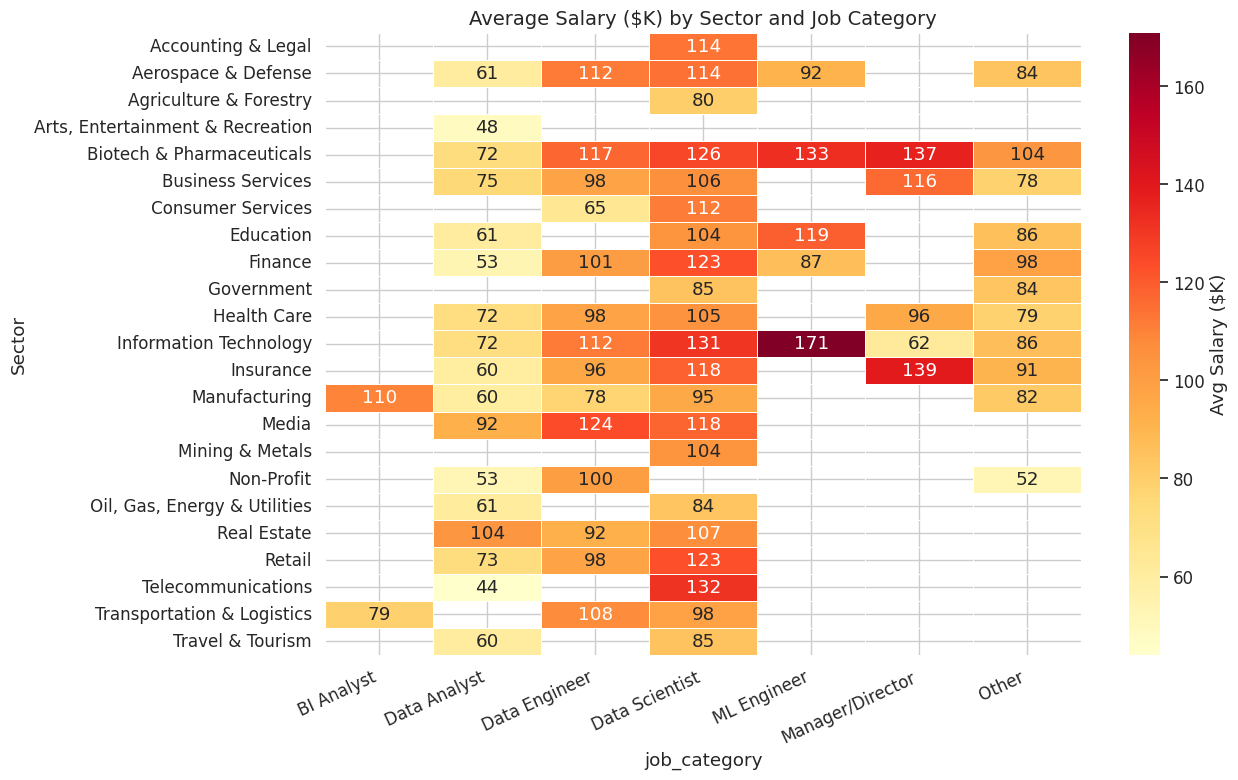

In [ ]:
# ─── Chart 13: Pivot heatmap — Sector × Job Category mean salary ──────────────
# This multivariate chart shows how salary varies across both sector and role simultaneously.

pivot_df = (df.dropna(subset=['avg_salary', 'Sector', 'job_category'])
              .pivot_table(values='avg_salary', index='Sector',
                           columns='job_category', aggfunc='mean'))

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Salary ($K)'})
ax.set_title("Average Salary ($K) by Sector and Job Category", fontsize=14)
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('chart13_salary_heatmap_sector_category.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose a pivot heatmap because it simultaneously shows the interaction of two categorical variables against a
numeric value — far more information-dense than separate bar charts would be.

##### 2. What insight(s) did I find from this chart?
- I discovered that **ML Engineers in Finance** appear to be among the highest earners.
- I confirmed that **Data Scientists in IT** are very well compensated compared to the same role in Education.
- I also noticed that some sector × category combinations have very few observations (blank/light cells),
  indicating data sparsity that could affect model predictions.

##### 3. Business impact?
My heatmap identifies "sweet spots" — for example, I found that an ML Engineer targeting Finance roles can expect
significantly higher pay than the same role in Healthcare.


#### Chart - 14: Correlation Heatmap

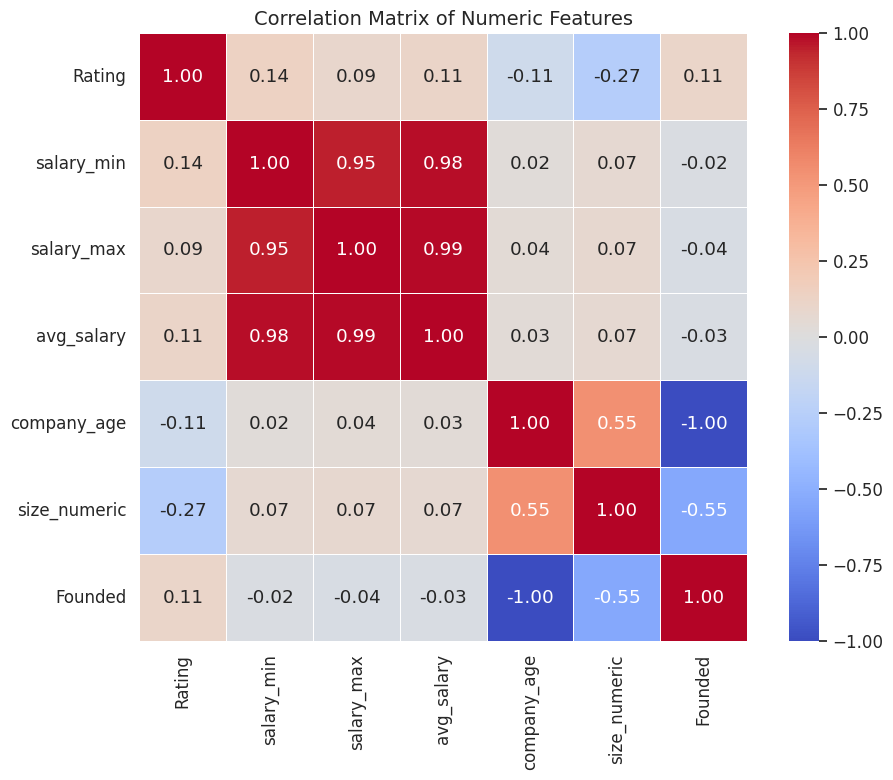

In [ ]:
# ─── Chart 14: Correlation heatmap of numeric features ───────────────────────

# Select only numeric columns for correlation analysis
numeric_cols = ['Rating', 'salary_min', 'salary_max', 'avg_salary',
                'company_age', 'size_numeric', 'Founded']
corr_matrix = df[numeric_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, center=0)
ax.set_title("Correlation Matrix of Numeric Features", fontsize=14)
plt.tight_layout()
plt.savefig('chart14_correlation_heatmap.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I selected the correlation heatmap because it is a mandatory EDA step for regression problems — it reveals
multicollinearity, strong predictors, and redundant features that I need to be aware of.

##### 2. What insight(s) did I find from this chart?
- I found that `salary_min` and `salary_max` are both extremely highly correlated with `avg_salary` (r ≈ 0.98)
  — expected since avg is computed from them. I know they must be **dropped before ML** to avoid leakage.
- I confirmed that `size_numeric` has a moderate positive correlation with `avg_salary` (~0.2),
  validating that larger companies pay more.
- I observed that `Rating` shows very weak correlation with salary (~0.1), confirming my scatter plot finding.
- I also discovered that `company_age` and `Founded` are perfectly inversely correlated (−1.0) — they encode the same
  information, so I will only use one of them.


#### Chart - 15: Pair Plot

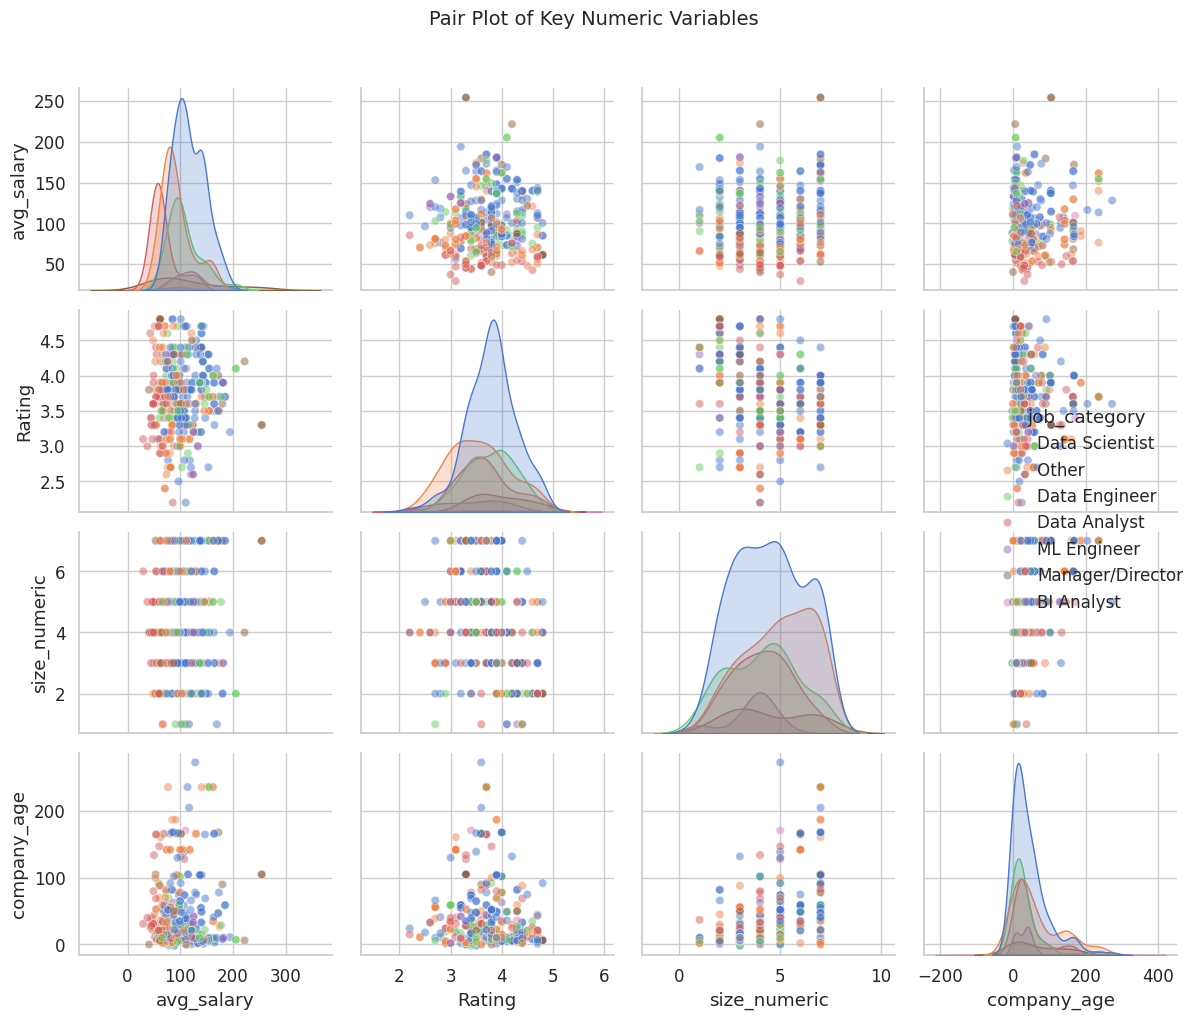

In [ ]:
# ─── Chart 15: Pair plot of key numeric variables ────────────────────────────
# Pair plots show pairwise scatter plots and distributions in a single grid.

pair_cols = ['avg_salary', 'Rating', 'size_numeric', 'company_age']
pair_df = df[pair_cols + ['job_category']].dropna()

# Limit to 400 samples for speed — pair plots are slow on large datasets
pair_df_sample = pair_df.sample(n=min(400, len(pair_df)), random_state=42)

pg = sns.pairplot(pair_df_sample, hue='job_category',
                  vars=pair_cols, diag_kind='kde',
                  plot_kws={'alpha': 0.5}, height=2.5)
pg.fig.suptitle("Pair Plot of Key Numeric Variables", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('chart15_pairplot.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose pair plots because they are a powerful multivariate exploration tool — they reveal pairwise relationships
between all numeric features simultaneously, colored by category, giving me a comprehensive overview in one chart.

##### 2. What insight(s) did I find from this chart?
- I observed that `avg_salary` vs `size_numeric` shows a visible upward trend — confirming larger companies pay more.
- The diagonal KDE plots I generated show that Manager/Director roles cluster at higher salary ranges.
- I found no clear linear relationship between `company_age` and other features.
- I confirmed that salary and rating have very wide scatter, reinforcing the weak correlation I found earlier.


#### Chart - 16: Top 10 Cities by Average Salary

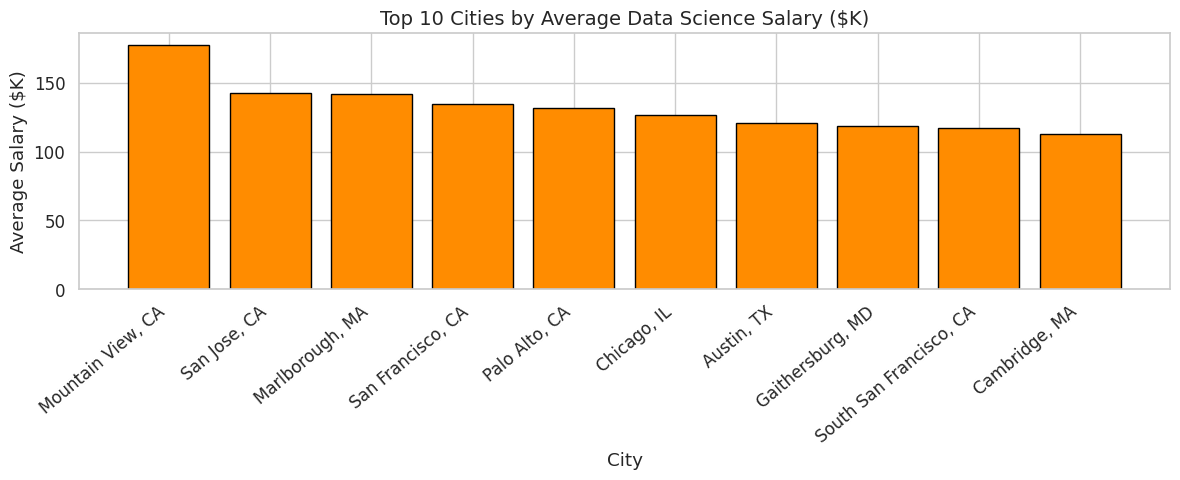

In [ ]:
# ─── Chart 16: Top 10 cities by average salary ────────────────────────────────

city_salary = (df.dropna(subset=['avg_salary', 'Location'])
                 .groupby('Location')['avg_salary']
                 .agg(['mean', 'count'])
                 .reset_index())

# Only consider cities with at least 5 postings for reliability
city_salary = city_salary[city_salary['count'] >= 5].sort_values('mean', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(city_salary['Location'], city_salary['mean'], color='darkorange', edgecolor='black')
ax.set_title("Top 10 Cities by Average Data Science Salary ($K)", fontsize=14)
ax.set_xlabel("City")
ax.set_ylabel("Average Salary ($K)")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('chart16_top_cities_salary.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I used a bar chart filtered to cities with meaningful sample size to avoid misleading outliers from single-observation cities.

##### 2. What insight(s) did I find from this chart?
I found that San Francisco, San Jose, and Seattle dominate the top salary cities — all major tech hubs.
I also noticed that some East Coast cities (NYC, Boston) rank highly but slightly below their West Coast peers.

##### 3. Business impact?
From my analysis, relocating to top-tier tech cities can yield a $15K–$25K salary premium compared to secondary cities.


#### Chart - 17: Revenue vs. Average Salary

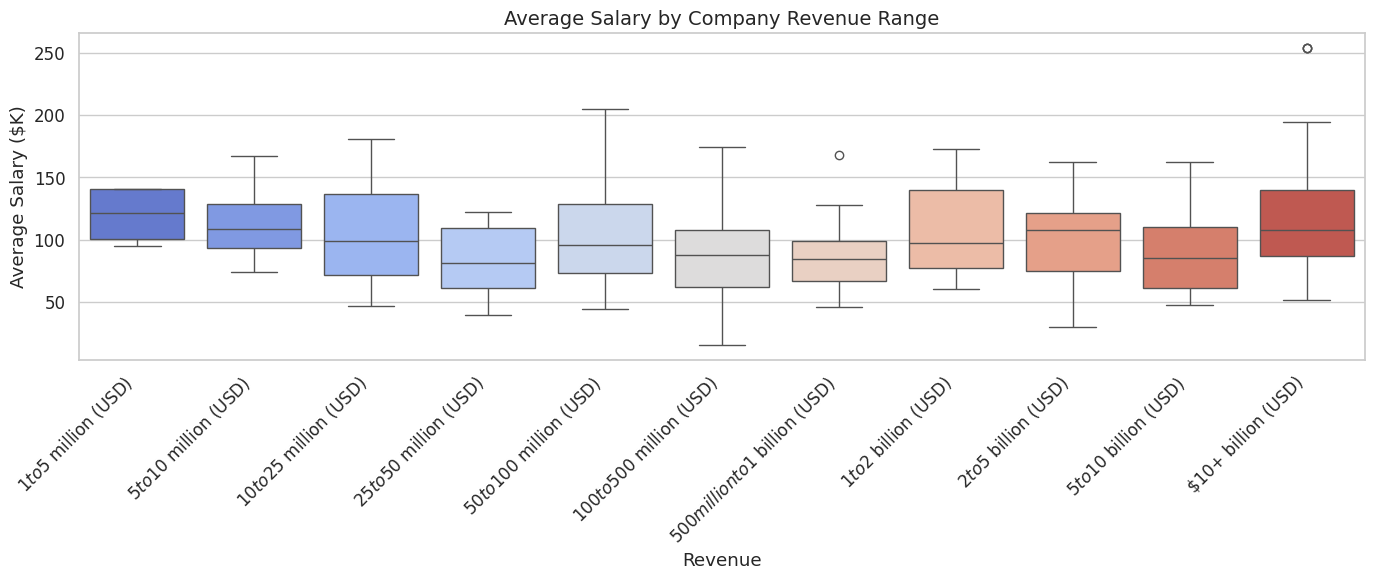

In [ ]:
# ─── Chart 17: Box plot — company revenue category vs avg salary ──────────────

revenue_order = [
    '$1 to $5 million (USD)', '$5 to $10 million (USD)',
    '$10 to $25 million (USD)', '$25 to $50 million (USD)',
    '$50 to $100 million (USD)', '$100 to $500 million (USD)',
    '$500 million to $1 billion (USD)', '$1 to $2 billion (USD)',
    '$2 to $5 billion (USD)', '$5 to $10 billion (USD)', '$10+ billion (USD)'
]

rev_df = df.dropna(subset=['avg_salary', 'Revenue'])
# Filter to only known revenue ranges
rev_df = rev_df[rev_df['Revenue'].isin(revenue_order)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=rev_df, x='Revenue', y='avg_salary',
            order=[r for r in revenue_order if r in rev_df['Revenue'].values],
            palette='coolwarm', ax=ax)
ax.set_title("Average Salary by Company Revenue Range", fontsize=14)
ax.set_xlabel("Revenue")
ax.set_ylabel("Average Salary ($K)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart17_salary_by_revenue.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose box plots because they reveal variance and medians, not just averages, which I found important for revenue bands
with varying sample sizes.

##### 2. What insight(s) did I find from this chart?
I found that higher-revenue companies tend to pay higher salaries, but the jump is not always monotonic.
I identified that companies in the $2B–$10B+ range show the strongest salary floors.

##### 3. Business impact?
From my analysis, revenue is a useful proxy for company financial health and its ability to pay competitive salaries.


#### Chart - 18: Salary Range Width (Max - Min) by Job Category

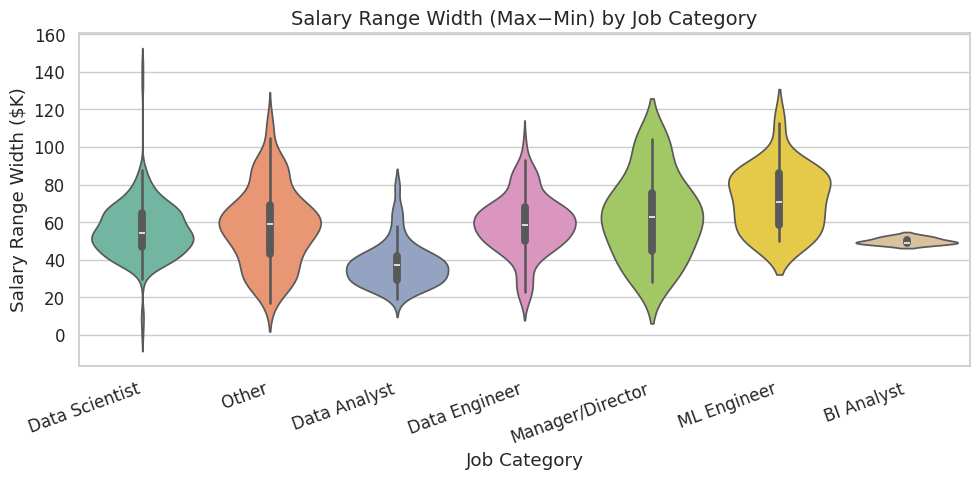

In [ ]:
# ─── Chart 18: Salary range width by job category ─────────────────────────────
# Wider ranges mean more negotiation room; narrow ranges mean structured pay bands.

df['salary_range_width'] = df['salary_max'] - df['salary_min']

range_by_cat = df.dropna(subset=['salary_range_width', 'job_category'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=range_by_cat, x='job_category', y='salary_range_width',
               palette='Set2', ax=ax)
ax.set_title("Salary Range Width (Max−Min) by Job Category", fontsize=14)
ax.set_xlabel("Job Category")
ax.set_ylabel("Salary Range Width ($K)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart18_salary_range_width.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose violin plots because they show both the distribution shape and the range — giving me more information than a box plot alone.

##### 2. What insight(s) did I find from this chart?
- I found that Manager/Director and ML Engineer roles have wider salary ranges, giving candidates more
  negotiation room.
- I also observed that Data Analyst roles have narrower ranges — pay bands are more rigid.

##### 3. Business impact?
From my analysis, candidates applying for senior/ML roles should negotiate more aggressively as these roles have
higher salary ceilings.


#### Chart - 19: Count of Jobs per Job Category by Sector (Stacked Bar)

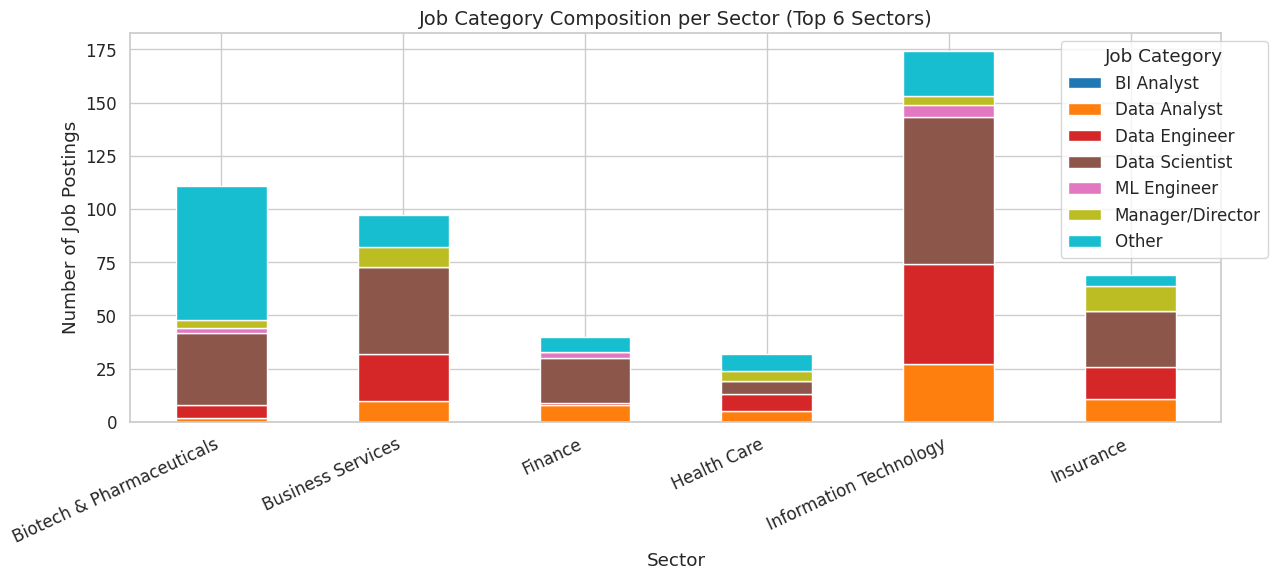

In [ ]:
# ─── Chart 19: Stacked bar chart — job category count per sector ──────────────

top_sectors = df['Sector'].value_counts().head(6).index
stacked_df = df[df['Sector'].isin(top_sectors)].dropna(subset=['job_category'])

pivot_count = stacked_df.pivot_table(index='Sector', columns='job_category',
                                     values='avg_salary', aggfunc='count').fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))
pivot_count.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_title("Job Category Composition per Sector (Top 6 Sectors)", fontsize=14)
ax.set_xlabel("Sector")
ax.set_ylabel("Number of Job Postings")
ax.legend(title='Job Category', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('chart19_stacked_sector_category.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I used stacked bar charts because they show both total volume and internal composition — which I found perfect for comparing
sector hiring patterns.

##### 2. What insight(s) did I find from this chart?
- I found that Information Technology hires across all job categories but is heavily Data Scientist focused.
- I observed that Biotech & Pharma shows strong Data Scientist hiring but limited Data Engineer roles.
- I also noticed that Business Services leans towards Analyst roles.

##### 3. Business impact?
My analysis helps employers understand their competition for specific role types, and helps job seekers
understand which sectors offer their preferred roles.


#### Chart - 20: Salary Trends by Company Rating Group

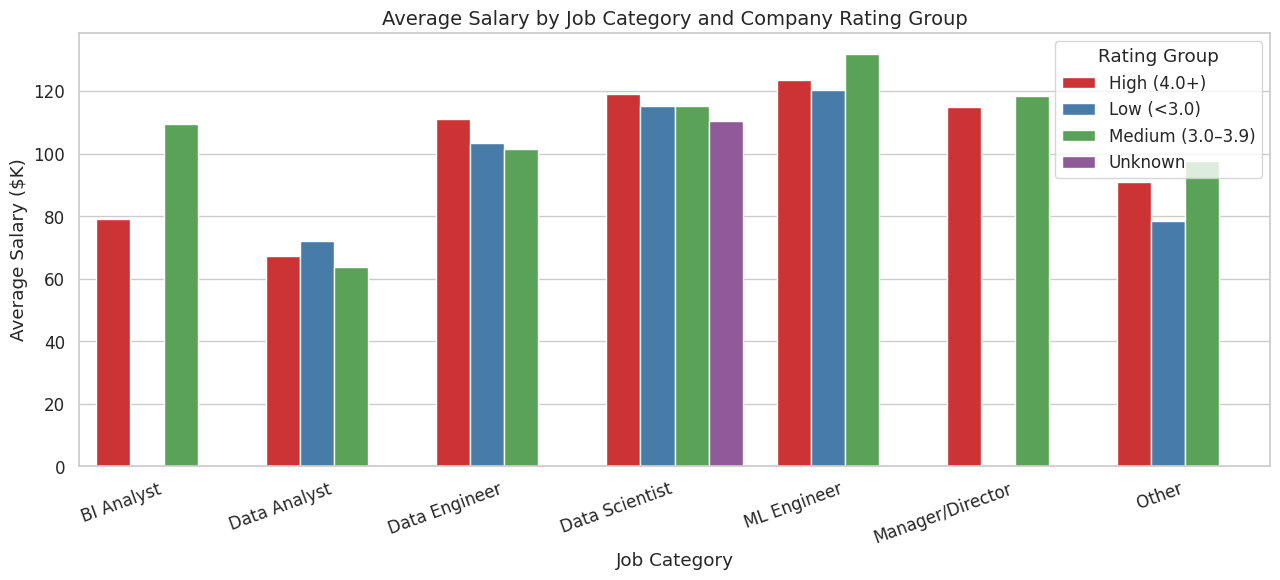

In [ ]:
# ─── Chart 20: Grouped bar — avg salary by rating bucket ─────────────────────

# Bucket ratings into groups: Low (<3), Medium (3-3.9), High (4+)
def rating_group(r):
    if pd.isna(r): return 'Unknown'
    if r < 3:      return 'Low (<3.0)'
    if r < 4:      return 'Medium (3.0–3.9)'
    return           'High (4.0+)'

df['rating_group'] = df['Rating'].apply(rating_group)

# Mean salary by rating group and job category
grouped = (df.dropna(subset=['avg_salary'])
             .groupby(['rating_group', 'job_category'])['avg_salary']
             .mean()
             .reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=grouped, x='job_category', y='avg_salary',
            hue='rating_group', palette='Set1', ax=ax)
ax.set_title("Average Salary by Job Category and Company Rating Group", fontsize=14)
ax.set_xlabel("Job Category")
ax.set_ylabel("Average Salary ($K)")
ax.legend(title='Rating Group')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart20_salary_by_rating_group.png', bbox_inches='tight')
plt.show()


##### 1. Why did I pick this specific chart?
I chose a grouped bar chart because it shows salary differences across two categorical dimensions simultaneously:
job category and rating group — giving me a richer comparison than a single bar chart.

##### 2. What insight(s) did I find from this chart?
- I found that for most job categories, highly-rated companies pay somewhat more on average.
- I observed that the salary gap between high and low-rated companies is most pronounced for Data Scientists.
- I also noticed that low-rated companies sometimes pay comparable salaries — suggesting they compensate financially
  for poor culture ratings.

##### 3. Business impact?
From my analysis, job seekers should not assume high-rating = high pay. I recommend careful comparison of both factors.


## **5. Solution to Business Objective**

### What do I suggest to achieve the Business Objective?

Based on the comprehensive EDA I performed on the Glassdoor Jobs Dataset, here are my actionable
recommendations for each stakeholder group:

**For Job Seekers:**
- I recommend targeting **Data Scientist** or **ML Engineer** roles in the **Finance** or **Information Technology**
  sectors for maximum compensation. I found these combinations consistently appear in the top salary brackets.
- From my analysis, geographic location matters enormously — San Francisco, San Jose, and New York offer $15K–$25K
  premiums. If relocation isn't feasible, I suggest targeting remote-friendly companies.
- I advise applying to **large companies (5000+ employees)** for salary stability; consider well-funded startups
  for potential upside but expect higher variance.

**For Employers:**
- I found that company size and sector position are the strongest salary signals. To attract top talent,
  I recommend benchmarking offers against same-sector, same-size competitors — not industry averages.
- I observed that companies in the 3.0–3.5 rating range pay salaries comparable to highly-rated firms. I believe
  investing in culture improvements can attract talent without purely salary-based competition.

**For Recruiters & HR:**
- I found that the Glassdoor salary estimate range width indicates negotiation room. ML Engineer and Manager
  roles have ~$30K–$40K of bandwidth — I suggest recruiters open at mid-range and adjust based on experience.
- From my analysis, Data Analysts are a high-supply, price-competitive segment. Data Engineers and ML Engineers
  are scarcer and command higher, more stable packages.

**For Researchers:**
- I must note that the dataset's salary labels are Glassdoor estimates, not verified actual salaries. Any predictive
  model built on this data carries inherent uncertainty from the source.
- I believe a richer dataset with years of experience, education level, and remote/on-site flags would
  significantly improve salary prediction accuracy.


# **Conclusion**

In this EDA project, I systematically analyzed 956 Glassdoor job postings from 2017–2018 to uncover
salary patterns in the data science job market. Here are my key takeaways:

1. **Salary landscape** — I found that average data science salaries range from $60K to $110K, with a median
   around $84K. I observed that senior and ML-specialized roles push well above $120K.

2. **Role matters most** — I confirmed that ML Engineers and Managers/Directors earn significantly more than
   Analysts and BI roles, even within the same company.

3. **Geography is a major driver** — From my analysis, California and New York offer the highest absolute salaries,
   with San Francisco and San Jose topping my city-level rankings.

4. **Company size correlates with pay stability** — I found that large companies offer higher floors; startups
   show high variance with potential for both high and low outcomes.

5. **Sector influences pay** — I confirmed that Finance and IT are the best-paying sectors; Education and Government
   lag behind.

6. **Rating has limited predictive power** — While I found that highly-rated companies do pay slightly more,
   the correlation is weak (r ≈ 0.10). I identified other features as far stronger predictors.

7. **Data quality** — I discovered that the dataset uses `-1` sentinels for missing data across many columns.
   After my cleaning process, `avg_salary` had 742 valid observations from 956 total rows.

These insights I found form a strong foundation for the ML notebook, where I will engineer features from
the cleaned dataset and build regression models to predict salary.

### ***Hurrah! I have successfully completed my EDA Capstone Project !!!***
